# Diagnostic EDA (On Raw Data)

In [2]:
import pandas as pd

In [3]:
raw_df = pd.read_csv('spotify_user_behavior_realistic_50000_rows.csv')

In [4]:
print("--- Dataset Shape ---")
print(raw_df.shape)

--- Dataset Shape ---
(50000, 18)


In [5]:
print("\n--- Data Types & Non-Null Counts ---")
print(raw_df.info())


--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  object 
 4   subscription_type               50000 non-null  object 
 5   subscription_status             50000 non-null  object 
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  object 
 9   ad_conversion_to_subscription   50000 non-null  object 
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64

In [6]:
print("\n--- Missing Values Per Column ---")
print(raw_df.isnull().sum())


--- Missing Values Per Column ---
user_id                           0
country                           0
age                               0
signup_date                       0
subscription_type                 0
subscription_status               0
months_inactive                   0
inactive_3_months_flag            0
ad_interaction                    0
ad_conversion_to_subscription     0
music_suggestion_rating_1_to_5    0
avg_listening_hours_per_week      0
favorite_genre                    0
most_liked_feature                0
desired_future_feature            0
primary_device                    0
playlists_created                 0
avg_skips_per_day                 0
dtype: int64


In [7]:
print(f"\nDuplicate Rows: {raw_df.duplicated().sum()}")


Duplicate Rows: 0


In [8]:
print("\n--- Statistical Summary ---")
print(raw_df.describe())


--- Statistical Summary ---
            user_id           age  months_inactive  inactive_3_months_flag  \
count  50000.000000  50000.000000     50000.000000            50000.000000   
mean   25000.500000     38.010280         1.533020                0.222460   
std    14433.901067     12.984989         1.952082                0.415903   
min        1.000000     16.000000         0.000000                0.000000   
25%    12500.750000     27.000000         0.000000                0.000000   
50%    25000.500000     38.000000         1.000000                0.000000   
75%    37500.250000     49.000000         2.000000                0.000000   
max    50000.000000     60.000000        18.000000                1.000000   

       music_suggestion_rating_1_to_5  avg_listening_hours_per_week  \
count                    50000.000000                  50000.000000   
mean                         3.644100                      9.988986   
std                          1.114424                  

In [9]:
categorical_cols = raw_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Unique values in {col}: {raw_df[col].nunique()}")

Unique values in country: 12
Unique values in signup_date: 2982
Unique values in subscription_type: 5
Unique values in subscription_status: 2
Unique values in ad_interaction: 2
Unique values in ad_conversion_to_subscription: 2
Unique values in favorite_genre: 12
Unique values in most_liked_feature: 8
Unique values in desired_future_feature: 6
Unique values in primary_device: 5


# Analytical EDA (On Cleaned Data)

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [11]:
cleaned_df = pd.read_csv('final_cleaned_spotify_data (1).csv')

In [12]:
sns.set_theme(style="whitegrid")

In [16]:
def analyze_shape(df, col_name, stage):
    # Calculate IQR for Outliers
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col_name] < (Q1 - 1.5 * IQR)) | (df[col_name] > (Q3 + 1.5 * IQR))).sum()

    print(f"--- {stage} Stats for {col_name} ---")
    print(f"Skewness: {df[col_name].skew():.4f}")
    print(f"Kurtosis: {df[col_name].kurt():.4f}")
    print(f"Outlier Count: {outliers}")
    print("-" * 30)

analyze_shape(raw_df, 'avg_listening_hours_per_week', "RAW")
analyze_shape(cleaned_df, 'avg_listening_hours_per_week', "CLEANED")

--- RAW Stats for avg_listening_hours_per_week ---
Skewness: 0.0319
Kurtosis: -0.1158
Outlier Count: 166
------------------------------
--- CLEANED Stats for avg_listening_hours_per_week ---
Skewness: -0.0367
Kurtosis: -0.2610
Outlier Count: 7
------------------------------


Text(0.5, 1.0, 'Distribution Shape (Skew: -0.04)')

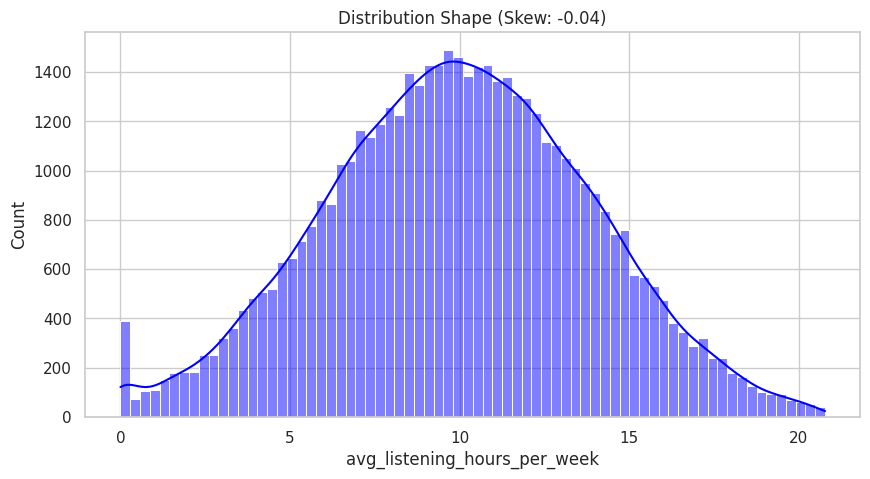

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(cleaned_df['avg_listening_hours_per_week'], kde=True, color='blue')
plt.title(f"Distribution Shape (Skew: {cleaned_df['avg_listening_hours_per_week'].skew():.2f})")

/tmp/ipykernel_5868/4037210150.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_df, x='age_group', palette='viridis', order=sorted(cleaned_df['age_group'].unique()))


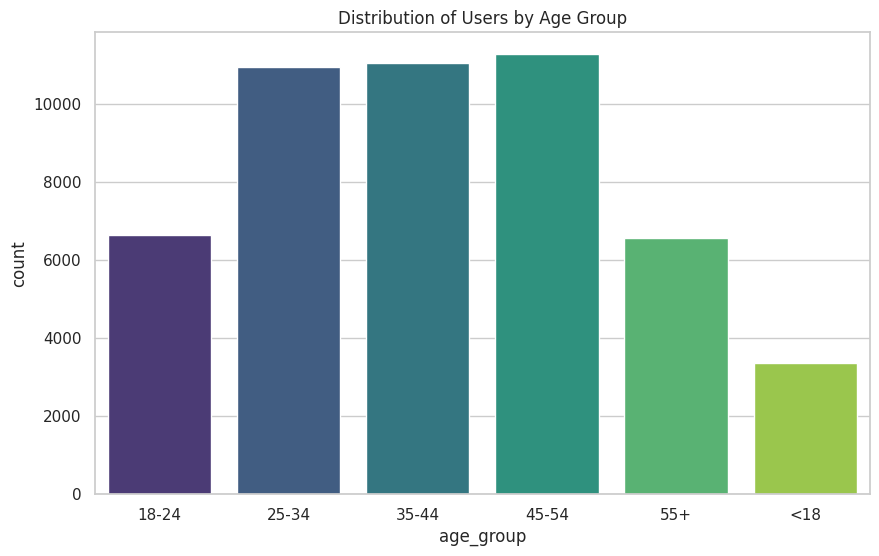

In [17]:
#Distribution of Key Categorical Variable (Age Groups)
plt.figure(figsize=(10, 6))
sns.countplot(data=cleaned_df, x='age_group', palette='viridis', order=sorted(cleaned_df['age_group'].unique()))
plt.title('Distribution of Users by Age Group')
plt.savefig('age_group_distribution.png')

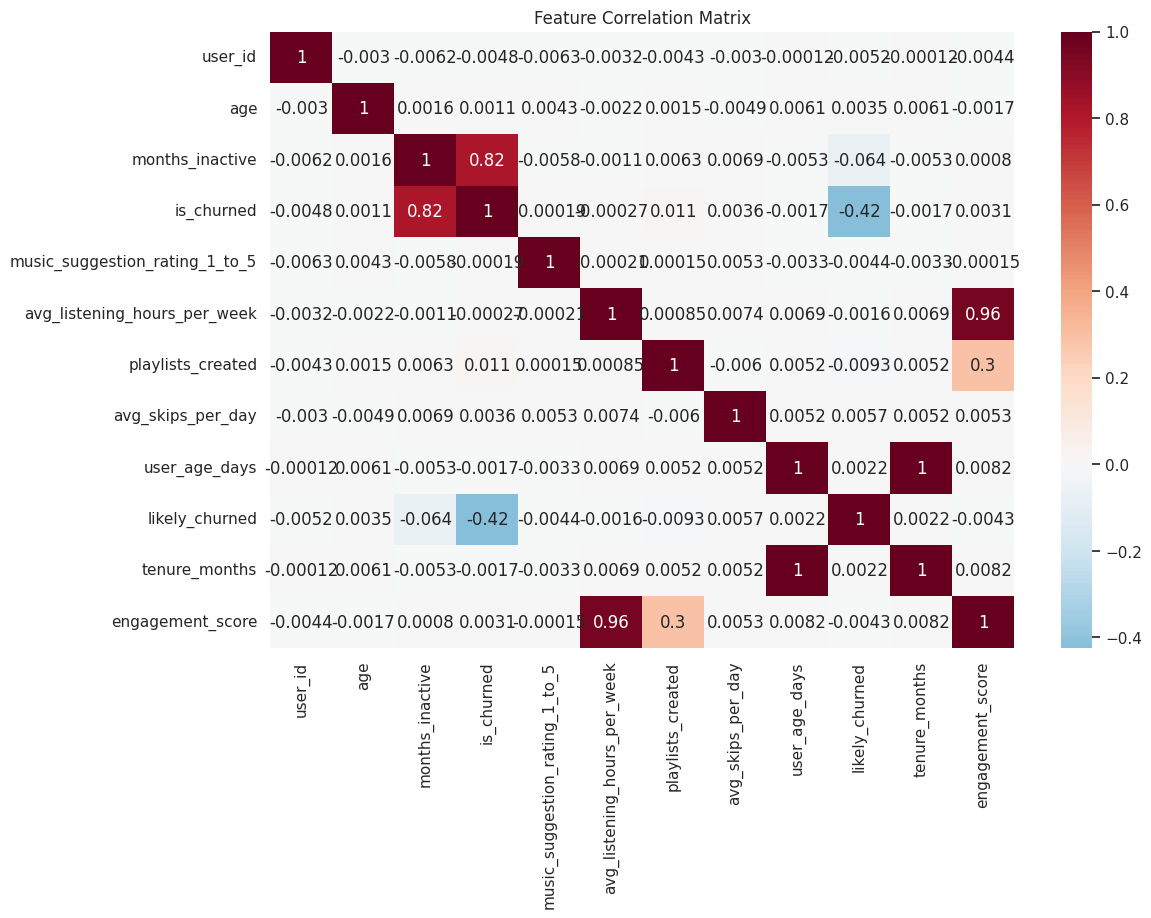

In [18]:
# 2. Correlation Analysis
# This helps us see which behaviors (like skips or listening hours) relate to churn
plt.figure(figsize=(12, 8))
numeric_df = cleaned_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix')
plt.savefig('correlation_heatmap.png')

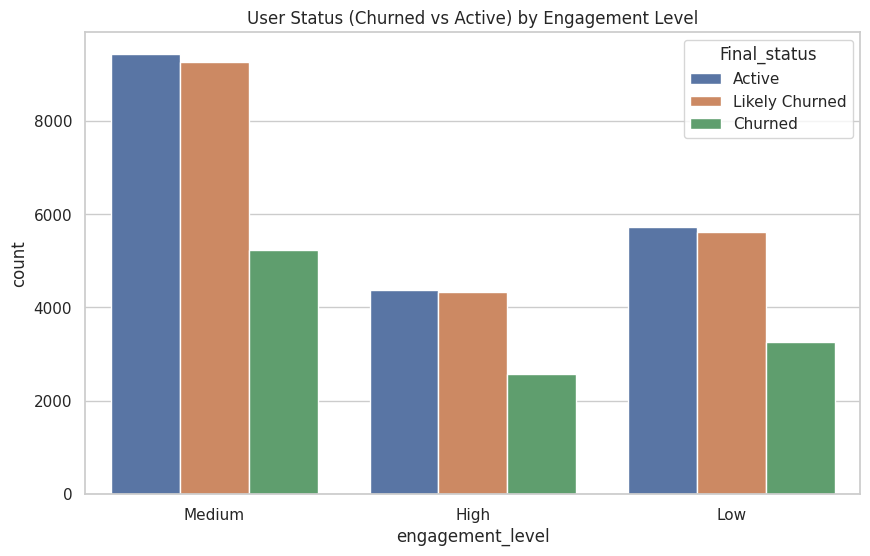

In [19]:
# 3. Relationship Analysis: Churn vs. Engagement
# Visualizing if higher engagement actually reduces churn
plt.figure(figsize=(10, 6))
sns.countplot(data=cleaned_df, x='engagement_level', hue='Final_status')
plt.title('User Status (Churned vs Active) by Engagement Level')
plt.savefig('churn_by_engagement.png')

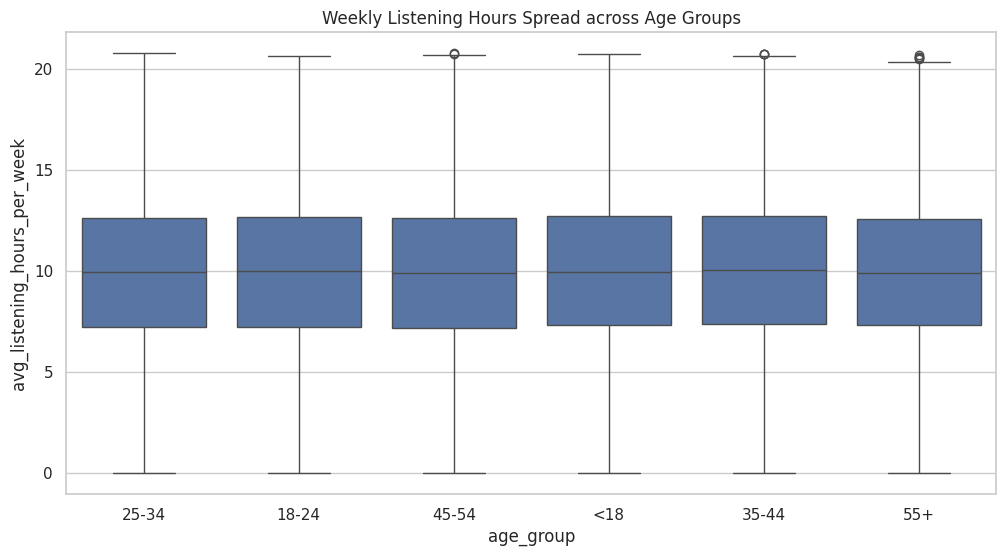

In [20]:
# 4. Outlier Detection: Listening Hours
# Using boxplots to see the spread and identify extreme users
plt.figure(figsize=(12, 6))
sns.boxplot(data=cleaned_df, x='age_group', y='avg_listening_hours_per_week')
plt.title('Weekly Listening Hours Spread across Age Groups')
plt.savefig('listening_hours_boxplot.png')